# 🛒 Prediksi Penjualan Retail Menggunakan Data Time-Series
## dengan Musiman dan Promosi Kompleks
### Dataset: Rossmann Store Sales (Kaggle)
### Jenis Model: **REGRESI** (Memprediksi nilai Sales)

---
**Tahapan:**
1. Data Understanding
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Data Splitting (3 kombinasi)
5. Model Building (3 Algoritma Regresi)
6. Hyperparameter Tuning
7. Model Evaluation
8. Model Comparison

## 📦 Install & Import Library

In [1]:
# Install library yang dibutuhkan (jalankan sekali)
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

# Coba import XGBoost (opsional tapi direkomendasikan)
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print('✅ XGBoost tersedia')
except ImportError:
    XGBOOST_AVAILABLE = False
    print('⚠️ XGBoost tidak tersedia, akan gunakan GradientBoosting sebagai pengganti')

print('✅ Semua library berhasil diimport!')

✅ XGBoost tersedia
✅ Semua library berhasil diimport!


---
## 1️⃣ DATA UNDERSTANDING
### 1.1 Load Dataset

In [2]:
# =====================================================================
# PENTING: Sesuaikan path file di bawah ini dengan lokasi file Anda
# Jika file ada di folder 'data/', gunakan path berikut:
# =====================================================================
TRAIN_PATH = 'data/train.csv'
STORE_PATH = 'data/store.csv'

# Load dataset
print('📂 Membaca dataset...')
train_full = pd.read_csv(TRAIN_PATH, parse_dates=['Date'], low_memory=False)
store      = pd.read_csv(STORE_PATH, sep=';', low_memory=False)

print(f'✅ train.csv  : {train_full.shape[0]:,} baris x {train_full.shape[1]} kolom')
print(f'✅ store.csv  : {store.shape[0]:,} baris x {store.shape[1]} kolom')

📂 Membaca dataset...
✅ train.csv  : 1,017,209 baris x 9 kolom
✅ store.csv  : 1,115 baris x 10 kolom


In [ ]:
# =====================================================================
# SAMPLING: Ambil 300.000 baris secara acak agar ringan di lokal
# Ini sudah cukup untuk menghasilkan model yang akurat
# =====================================================================
SAMPLE_SIZE = 300_000
np.random.seed(42)

# Hanya ambil data di mana toko buka dan ada penjualan
train_filtered = train_full[(train_full['Open'] == 1) & (train_full['Sales'] > 0)].copy()
train = train_filtered.sample(n=min(SAMPLE_SIZE, len(train_filtered)), random_state=42).reset_index(drop=True)

print(f'📊 Data setelah sampling: {train.shape[0]:,} baris')
print(f'   (dari total {train_full.shape[0]:,} baris — diambil {len(train)/len(train_full)*100:.1f}%)')

📊 Data setelah sampling: 300,000 baris
   (dari total 1,017,209 baris — diambil 29.5%)


In [4]:
# Tampilkan 5 baris pertama train
print('=== Tampilan train.csv ===')
train.head()

=== Tampilan train.csv ===


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,257,2,2015-06-16,5934,657,1,1,0,0
1,4,3,2013-10-30,7800,1147,1,0,0,0
2,593,3,2014-11-05,9111,1135,1,1,0,0
3,1026,3,2013-06-19,7831,978,1,1,0,0
4,19,1,2014-04-28,10046,844,1,1,0,0


In [5]:
# Tampilkan 5 baris pertama store
print('=== Tampilan store.csv ===')
store.head()

=== Tampilan store.csv ===


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### 1.2 Penjelasan Fitur/Variabel Dataset

**train.csv:**
| Kolom | Keterangan |
|-------|------------|
| Store | ID toko (1–1115) |
| DayOfWeek | Hari dalam seminggu (1=Senin, 7=Minggu) |
| Date | Tanggal penjualan |
| Sales | **Target** — Total penjualan hari itu (dalam €) |
| Customers | Jumlah pelanggan |
| Open | 0 = tutup, 1 = buka |
| Promo | 1 = ada promosi |
| StateHoliday | Libur negara (a/b/c/0) |
| SchoolHoliday | Libur sekolah (0/1) |

**store.csv:**
| Kolom | Keterangan |
|-------|------------|
| StoreType | Tipe toko (a/b/c/d) |
| Assortment | Level assortment (a/b/c) |
| CompetitionDistance | Jarak ke kompetitor terdekat (meter) |
| Promo2 | Promo berkelanjutan (0/1) |
| Promo2SinceWeek | Minggu mulai Promo2 |
| PromoInterval | Bulan mulai promosi |

In [6]:
# Statistik deskriptif
print('=== Statistik Deskriptif train.csv ===')
train.describe()

=== Statistik Deskriptif train.csv ===


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,300000.000000,300000.000000,300000,300000.000000,300000.000000,300000.0,300000.000000,300000.000000
mean,558.175633,3.519967,2014-04-10 19:14:11.903999,6952.692840,762.755910,1.0,0.446010,0.193043
min,1.000000,1.000000,2013-01-01 00:00:00,133.000000,18.000000,1.0,0.000000,0.000000
25%,280.000000,2.000000,2013-08-17 00:00:00,4857.000000,518.000000,1.0,0.000000,0.000000
50%,557.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000
75%,838.000000,5.000000,2014-12-10 00:00:00,8361.000000,893.000000,1.0,1.000000,0.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,37376.000000,7388.000000,1.0,1.000000,1.000000
std,322.006086,1.724173,NaN,3098.990197,400.825115,0.0,0.497077,0.394687


In [7]:
print('=== Statistik Deskriptif store.csv ===')
store.describe()

=== Statistik Deskriptif store.csv ===


,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [8]:
# Info tipe data
print('=== Info train.csv ===')
train.info()

=== Info train.csv ===
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Store          300000 non-null  int64         
 1   DayOfWeek      300000 non-null  int64         
 2   Date           300000 non-null  datetime64[us]
 3   Sales          300000 non-null  int64         
 4   Customers      300000 non-null  int64         
 5   Open           300000 non-null  int64         
 6   Promo          300000 non-null  int64         
 7   StateHoliday   300000 non-null  str           
 8   SchoolHoliday  300000 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 20.6 MB


---
## 2️⃣ DATA PREPROCESSING
### 2.1 Merge Dataset

In [9]:
# Gabungkan train dengan store berdasarkan kolom 'Store'
df = pd.merge(train, store, on='Store', how='left')
print(f'✅ Dataset setelah merge: {df.shape[0]:,} baris x {df.shape[1]} kolom')

✅ Dataset setelah merge: 300,000 baris x 18 kolom


### 2.2 Cek Missing Values

=== Kolom dengan Missing Values ===
                           Missing Count  Missing %
Promo2SinceYear                   150366      50.12
Promo2SinceWeek                   150366      50.12
PromoInterval                     150366      50.12
CompetitionOpenSinceMonth          95546      31.85
CompetitionOpenSinceYear           95546      31.85
CompetitionDistance                  771       0.26


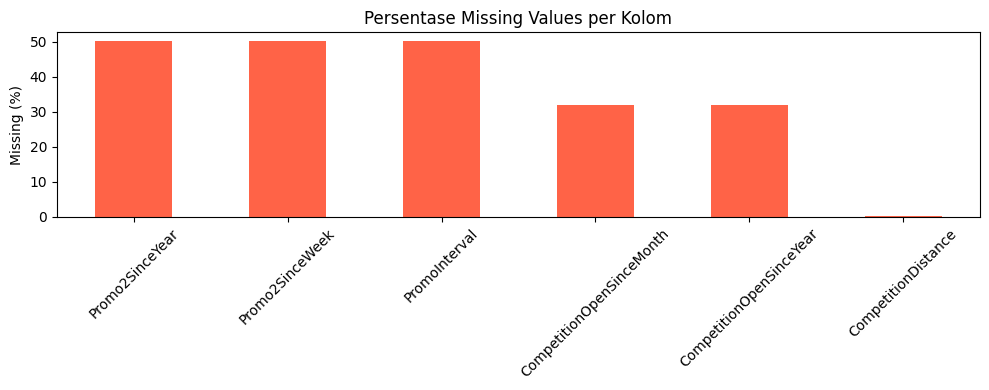

In [10]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Kolom dengan Missing Values ===')
print(missing_df)

# Visualisasi
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Persentase Missing Values per Kolom')
    ax.set_ylabel('Missing (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('✅ Tidak ada missing values!')

### 2.3 Handle Missing Values

In [11]:
# Isi missing values dengan strategi yang tepat

# CompetitionDistance: isi dengan median (karena ada outlier)
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

# CompetitionOpenSinceMonth/Year: isi dengan 0
for col in ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Promo2SinceWeek/Year: isi dengan 0
for col in ['Promo2SinceWeek', 'Promo2SinceYear']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# PromoInterval: isi dengan 'None'
if 'PromoInterval' in df.columns:
    df['PromoInterval'] = df['PromoInterval'].fillna('None')

print(f'✅ Missing values setelah handling: {df.isnull().sum().sum()}')

✅ Missing values setelah handling: 0


### 2.4 Feature Engineering dari Kolom Date

In [12]:
# Ekstrak fitur waktu dari kolom Date
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Date'].dt.quarter

# Tandai apakah hari itu akhir bulan
df['IsEndOfMonth'] = (df['Date'].dt.is_month_end).astype(int)

print('✅ Fitur waktu berhasil diekstrak')
print(df[['Date','Year','Month','Day','WeekOfYear','Quarter','IsEndOfMonth']].head())

✅ Fitur waktu berhasil diekstrak
        Date  Year  Month  Day  WeekOfYear  Quarter  IsEndOfMonth
0 2015-06-16  2015      6   16          25        2             0
1 2013-10-30  2013     10   30          44        4             0
2 2014-11-05  2014     11    5          45        4             0
3 2013-06-19  2013      6   19          25        2             0
4 2014-04-28  2014      4   28          18        2             0


### 2.5 Encoding Variabel Kategorikal

In [13]:
le = LabelEncoder()

# Kolom kategorikal yang perlu di-encode
cat_cols = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        print(f'✅ Encoded: {col}')

print('\n✅ Semua variabel kategorikal sudah di-encode!')

✅ Encoded: StoreType
✅ Encoded: Assortment
✅ Encoded: StateHoliday
✅ Encoded: PromoInterval

✅ Semua variabel kategorikal sudah di-encode!


### 2.6 Handle Outlier pada Target (Sales)

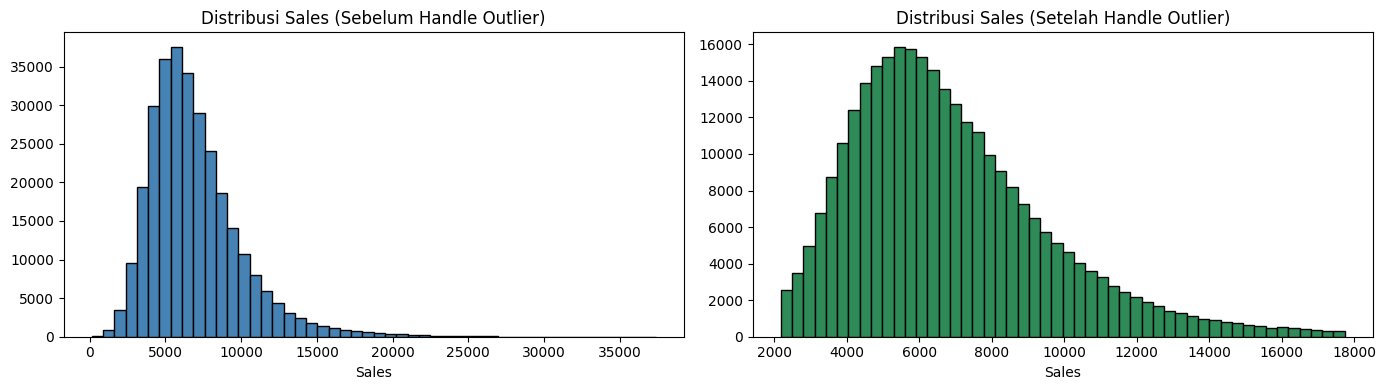

✅ Data setelah handle outlier: 294,011 baris


In [14]:
# Visualisasi distribusi Sales sebelum
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Sales (Sebelum Handle Outlier)')
axes[0].set_xlabel('Sales')

# Hapus outlier ekstrem menggunakan IQR
Q1 = df['Sales'].quantile(0.01)
Q3 = df['Sales'].quantile(0.99)
df = df[(df['Sales'] >= Q1) & (df['Sales'] <= Q3)]

axes[1].hist(df['Sales'], bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Distribusi Sales (Setelah Handle Outlier)')
axes[1].set_xlabel('Sales')

plt.tight_layout()
plt.show()
print(f'✅ Data setelah handle outlier: {len(df):,} baris')

### 2.7 Pilih Fitur dan Target

In [15]:
# Kolom yang tidak digunakan sebagai fitur
DROP_COLS = ['Date', 'Sales', 'Customers']  # Customers bocorkan target, Date sudah diekstrak

# Pilih semua kolom numerik sebagai fitur
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in DROP_COLS]

X = df[feature_cols].copy()
y = df['Sales'].copy()

print(f'✅ Jumlah fitur: {len(feature_cols)}')
print(f'✅ Fitur yang digunakan: {feature_cols}')
print(f'✅ Jumlah sampel: {len(X):,}')

✅ Jumlah fitur: 21
✅ Fitur yang digunakan: ['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter', 'IsEndOfMonth']
✅ Jumlah sampel: 294,011


### 2.8 Normalisasi Data

In [16]:
# Simpan nama fitur
feature_names = X.columns.tolist()

# Standarisasi untuk Linear Regression (tree-based tidak butuh, tapi kita siapkan)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_names)

print('✅ Data berhasil dinormalisasi (StandardScaler)')
print(X_scaled.describe().round(2))

✅ Data berhasil dinormalisasi (StandardScaler)
           Store  DayOfWeek      Open      Promo  StateHoliday  SchoolHoliday  \
count  294011.00  294011.00  294011.0  294011.00     294011.00      294011.00   
mean       -0.00      -0.00       0.0       0.00         -0.00          -0.00   
std         1.00       1.00       0.0       1.00          1.00           1.00   
min        -1.73      -1.46       0.0      -0.90         -0.03          -0.49   
25%        -0.86      -0.88       0.0      -0.90         -0.03          -0.49   
50%        -0.00      -0.30       0.0      -0.90         -0.03          -0.49   
75%         0.87       0.87       0.0       1.11         -0.03          -0.49   
max         1.73       2.04       0.0       1.11         68.31           2.04   

       StoreType  Assortment  CompetitionDistance  CompetitionOpenSinceMonth  \
count  294011.00   294011.00            294011.00                  294011.00   
mean       -0.00       -0.00                -0.00              

---
## 3️⃣ EXPLORATORY DATA ANALYSIS (EDA)

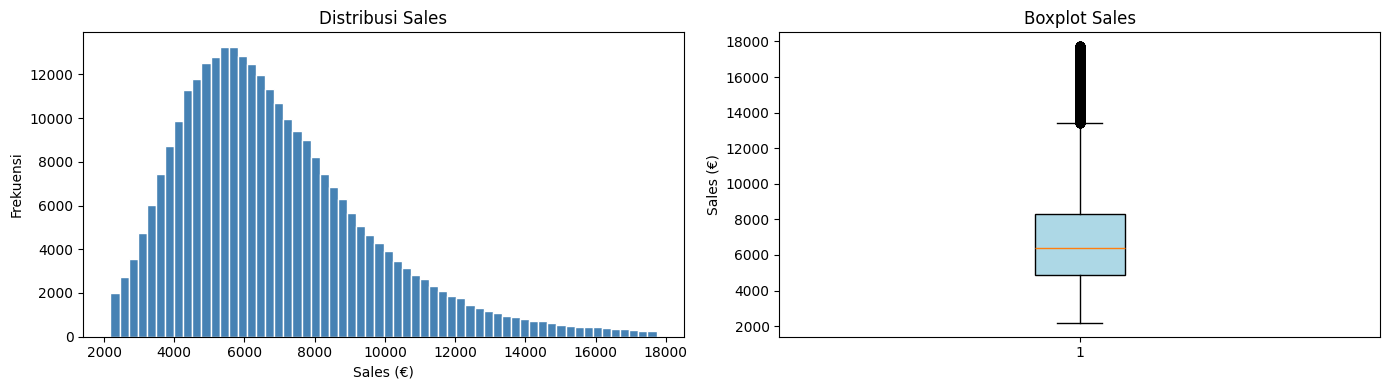

Rata-rata Sales  : €6,865
Median Sales     : €6,369
Std Sales        : €2,740
Min Sales        : €2,183
Max Sales        : €17,737


In [17]:
# ---- 3.1 Distribusi Sales ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Sales')
axes[0].set_xlabel('Sales (€)')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot Sales')
axes[1].set_ylabel('Sales (€)')

plt.tight_layout()
plt.show()

print(f'Rata-rata Sales  : €{y.mean():,.0f}')
print(f'Median Sales     : €{y.median():,.0f}')
print(f'Std Sales        : €{y.std():,.0f}')
print(f'Min Sales        : €{y.min():,.0f}')
print(f'Max Sales        : €{y.max():,.0f}')

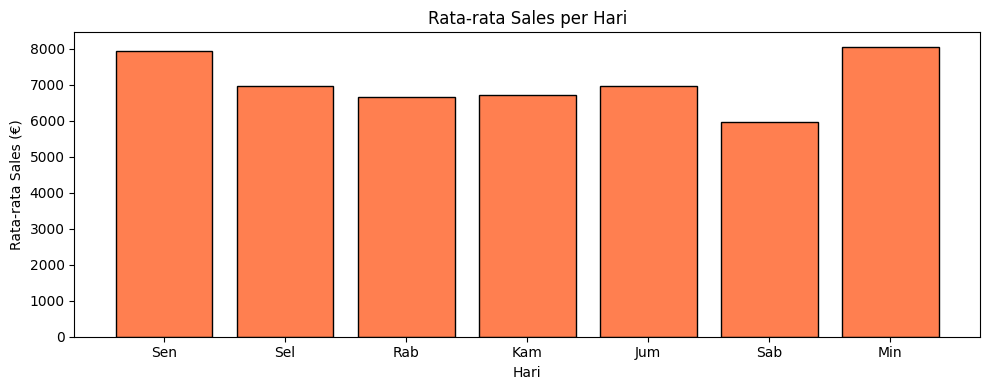

💡 Insight: Senin memiliki penjualan tertinggi karena efek akhir pekan.


In [18]:
# ---- 3.2 Sales berdasarkan Hari dalam Seminggu ----
day_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
day_labels = {1:'Sen',2:'Sel',3:'Rab',4:'Kam',5:'Jum',6:'Sab',7:'Min'}
day_sales['DayName'] = day_sales['DayOfWeek'].map(day_labels)

plt.figure(figsize=(10, 4))
plt.bar(day_sales['DayName'], day_sales['Sales'], color='coral', edgecolor='black')
plt.title('Rata-rata Sales per Hari')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Sales (€)')
plt.tight_layout()
plt.show()

print('💡 Insight: Senin memiliki penjualan tertinggi karena efek akhir pekan.')

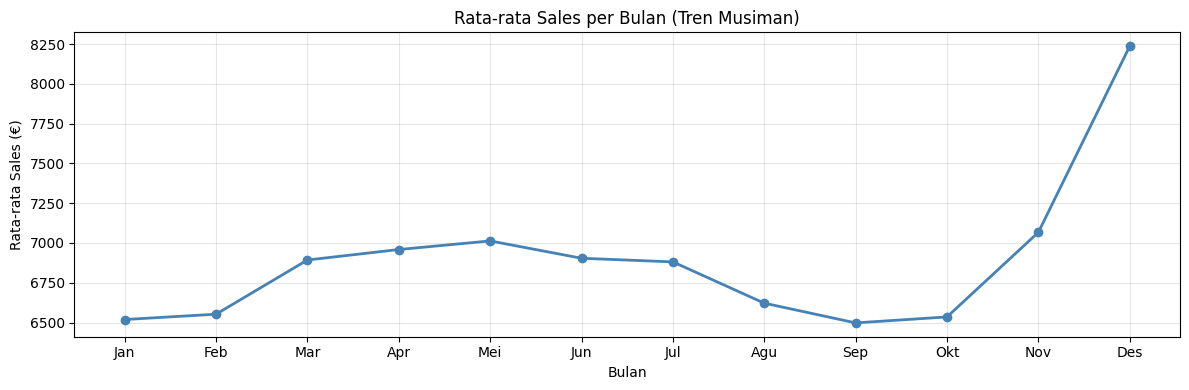

💡 Insight: Desember memiliki penjualan tertinggi (musim natal/akhir tahun).


In [19]:
# ---- 3.3 Sales berdasarkan Bulan ----
month_sales = df.groupby('Month')['Sales'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']

plt.figure(figsize=(12, 4))
plt.plot(month_sales['Month'], month_sales['Sales'], marker='o', color='steelblue', linewidth=2)
plt.xticks(range(1,13), month_names)
plt.title('Rata-rata Sales per Bulan (Tren Musiman)')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Sales (€)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('💡 Insight: Desember memiliki penjualan tertinggi (musim natal/akhir tahun).')

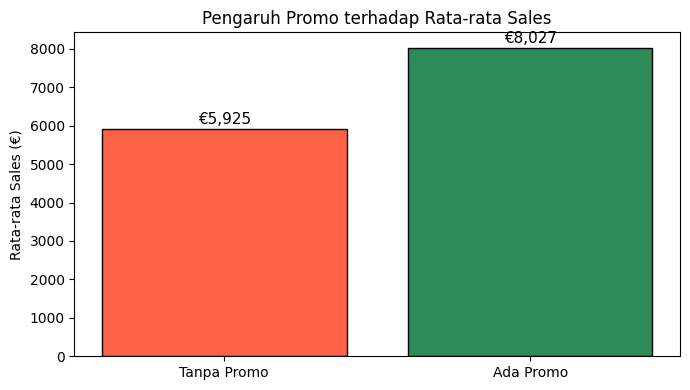

💡 Promo meningkatkan Sales rata-rata 35.5%


In [20]:
# ---- 3.4 Pengaruh Promo terhadap Sales ----
promo_sales = df.groupby('Promo')['Sales'].mean()

plt.figure(figsize=(7, 4))
bars = plt.bar(['Tanpa Promo', 'Ada Promo'], promo_sales.values, color=['tomato','seagreen'], edgecolor='black')
for bar, val in zip(bars, promo_sales.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'€{val:,.0f}', 
             ha='center', va='bottom', fontsize=11)
plt.title('Pengaruh Promo terhadap Rata-rata Sales')
plt.ylabel('Rata-rata Sales (€)')
plt.tight_layout()
plt.show()

print(f'💡 Promo meningkatkan Sales rata-rata {((promo_sales[1]/promo_sales[0])-1)*100:.1f}%')

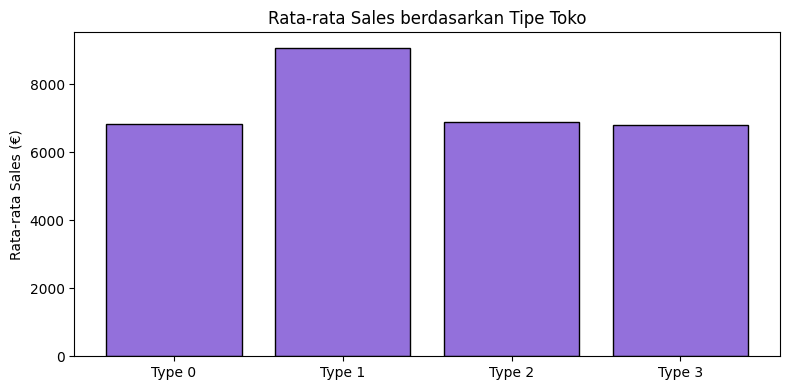

In [21]:
# ---- 3.5 Sales berdasarkan Tipe Toko ----
storetype_map = {i:c for i,c in enumerate(sorted(df.groupby('StoreType')['Sales'].mean().index))}
storetype_sales = df.groupby('StoreType')['Sales'].mean()

plt.figure(figsize=(8, 4))
plt.bar(range(len(storetype_sales)), storetype_sales.values, color='mediumpurple', edgecolor='black')
plt.xticks(range(len(storetype_sales)), [f'Type {i}' for i in storetype_sales.index])
plt.title('Rata-rata Sales berdasarkan Tipe Toko')
plt.ylabel('Rata-rata Sales (€)')
plt.tight_layout()
plt.show()

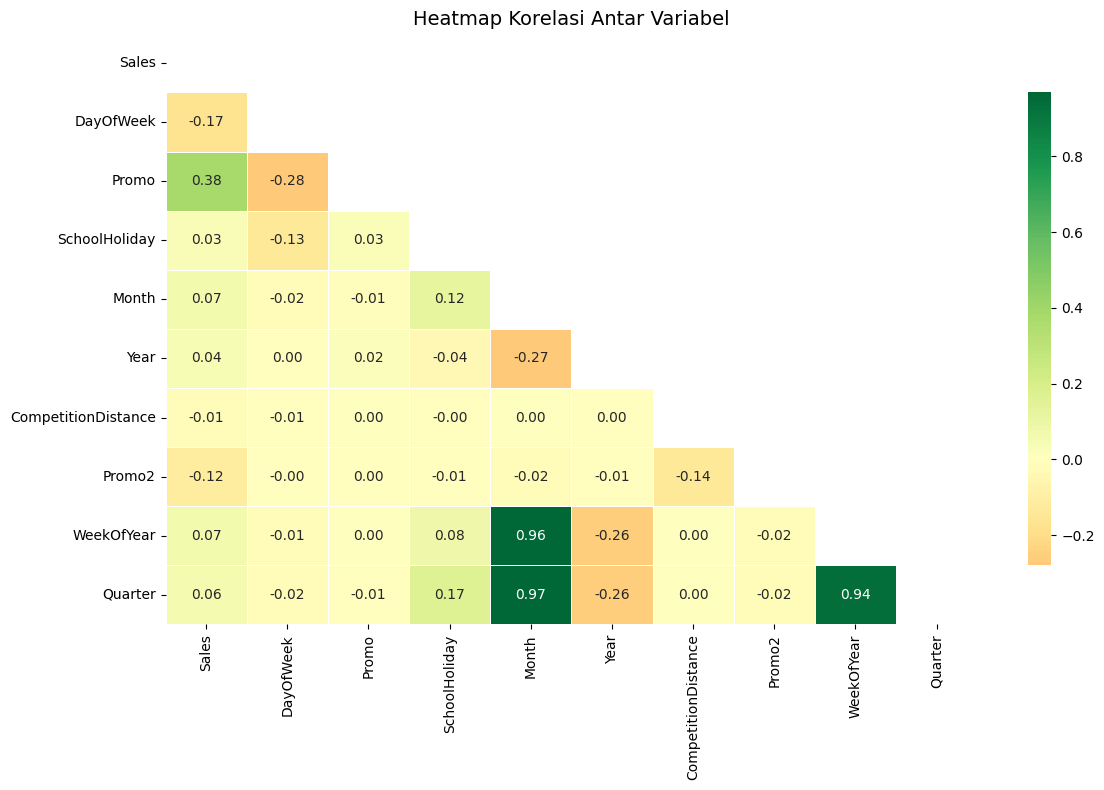

💡 Promo memiliki korelasi positif terkuat terhadap Sales.


In [22]:
# ---- 3.6 Heatmap Korelasi ----
# Pilih kolom numerik utama untuk korelasi
corr_cols = ['Sales','DayOfWeek','Promo','SchoolHoliday','Month','Year',
             'CompetitionDistance','Promo2','WeekOfYear','Quarter']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Variabel', fontsize=14)
plt.tight_layout()
plt.show()

print('💡 Promo memiliki korelasi positif terkuat terhadap Sales.')

---
## 4️⃣ DATA SPLITTING
### 3 Kombinasi Rasio Train:Test

In [23]:
# Kita gunakan X (belum di-scale) untuk tree-based, X_scaled untuk LinearRegression
X_data = X.copy().fillna(0)  # pastikan tidak ada NaN

# ========== Split 1: 70% Train - 30% Test ==========
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_data, y, test_size=0.30, random_state=42)

# ========== Split 2: 80% Train - 20% Test ==========
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_data, y, test_size=0.20, random_state=42)

# ========== Split 3: 90% Train - 10% Test ==========
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_data, y, test_size=0.10, random_state=42)

# Scaled versions untuk LinearRegression
X_sc = X_scaled.copy().fillna(0)
X_sc_tr1, X_sc_te1, _, _ = train_test_split(X_sc, y, test_size=0.30, random_state=42)
X_sc_tr2, X_sc_te2, _, _ = train_test_split(X_sc, y, test_size=0.20, random_state=42)
X_sc_tr3, X_sc_te3, _, _ = train_test_split(X_sc, y, test_size=0.10, random_state=42)

print('✅ Data splitting berhasil!')
print(f'\nSplit 1 (70:30) → Train: {len(X_train1):,} | Test: {len(X_test1):,}')
print(f'Split 2 (80:20) → Train: {len(X_train2):,} | Test: {len(X_test2):,}')
print(f'Split 3 (90:10) → Train: {len(X_train3):,} | Test: {len(X_test3):,}')

✅ Data splitting berhasil!

Split 1 (70:30) → Train: 205,807 | Test: 88,204
Split 2 (80:20) → Train: 235,208 | Test: 58,803
Split 3 (90:10) → Train: 264,609 | Test: 29,402


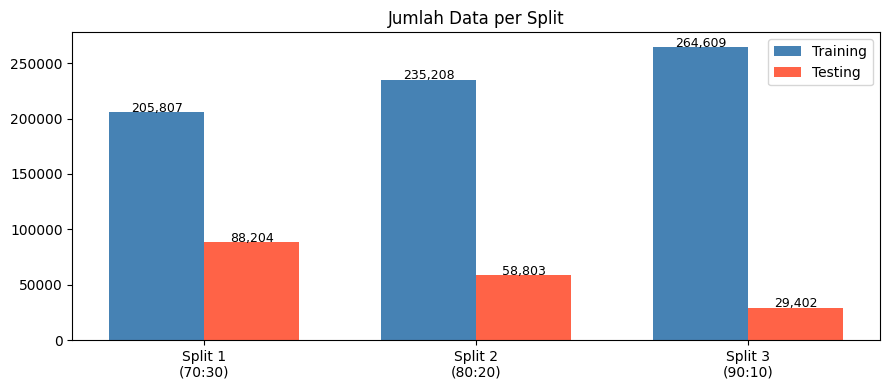

In [24]:
# Visualisasi proporsi split
splits = ['70:30', '80:20', '90:10']
train_sizes = [len(X_train1), len(X_train2), len(X_train3)]
test_sizes  = [len(X_test1), len(X_test2), len(X_test3)]

x_pos = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x_pos - width/2, train_sizes, width, label='Training', color='steelblue')
bars2 = ax.bar(x_pos + width/2, test_sizes,  width, label='Testing',  color='tomato')

for b in bars1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200, f'{b.get_height():,}', ha='center', fontsize=9)
for b in bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+200, f'{b.get_height():,}', ha='center', fontsize=9)

ax.set_title('Jumlah Data per Split')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Split {i+1}\n({s})' for i,s in enumerate(splits)])
ax.legend()
plt.tight_layout()
plt.show()

---
## 5️⃣ MODEL BUILDING
### Algoritma yang digunakan:
1. **LightGBM Regressor** — High-performance gradient boosting (Leaf-wise)
2. **Random Forest Regressor** — Ensemble tree
3. **Gradient Boosting / XGBoost** — Boosting ensemble

### Metrik Evaluasi Regresi:
- **R² Score** — Seberapa baik model menjelaskan variansi data (Target: ≥ 0.85 = 85%)
- **MAE** — Mean Absolute Error
- **RMSE** — Root Mean Squared Error

In [25]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='', split_name=''):
    """Train model dan kembalikan metrik evaluasi"""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    
    print(f'  [{split_name}] R²={r2:.4f} ({r2*100:.2f}%) | MAE={mae:,.0f} | RMSE={rmse:,.0f}')
    return {'Model': model_name, 'Split': split_name, 'R2': round(r2, 4), 
            'R2_pct': round(r2*100, 2), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'y_pred': y_pred, 'model_obj': model}

print('✅ Fungsi evaluasi siap!')

✅ Fungsi evaluasi siap!


In [26]:
from lightgbm import LGBMRegressor

results = []  # simpan semua hasil
trained_models = {}  # simpan model terbaik

splits_data = [
    ('Split1_70:30', X_sc_tr1, y_train1, X_sc_te1, y_test1),
    ('Split2_80:20', X_sc_tr2, y_train2, X_sc_te2, y_test2),
    ('Split3_90:10', X_sc_tr3, y_train3, X_sc_te3, y_test3),
]

# ==========================================
# MODEL 1: LightGBM Regressor
# ==========================================
print('\n💡 MODEL 1: LightGBM Regressor')
print('-' * 55)

for split_name, X_tr, y_tr, X_te, y_te in splits_data:
    # Menggunakan LGBMRegressor dengan parameter dasar yang kuat
    model = LGBMRegressor(
        n_estimators=1000, 
        learning_rate=0.05, 
        num_leaves=31, 
        random_state=42, 
        n_jobs=-1
    )
    
    # Memanggil fungsi evaluate_model milikmu
    res = evaluate_model(model, X_tr, y_tr, X_te, y_te, 'LightGBM', split_name)
    
    # Simpan hasil metrik (mengecualikan objek model dan prediksi agar tidak berat)
    results.append({k: v for k, v in res.items() if k not in ['y_pred','model_obj']})
    
    # Simpan model terbaik ke dalam dictionary
    if 'LightGBM' not in trained_models:
        trained_models['LightGBM'] = res['model_obj']


💡 MODEL 1: LightGBM Regressor
-------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 730
[LightGBM] [Info] Number of data points in the train set: 205807, number of used features: 20
[LightGBM] [Info] Start training from score 6863.379258
  [Split1_70:30] R²=0.8730 (87.30%) | MAE=712 | RMSE=977
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004876 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 730
[LightGBM] [Info] Number of data points in the train set: 235208, number of used features: 20
[LightGBM] [Info] Start training from score 6861.639791
  [Split2_80:20] R²=0.8738 (87.38%) | 

In [27]:
splits_data_raw = [
    ('Split1_70:30', X_train1, y_train1, X_test1, y_test1),
    ('Split2_80:20', X_train2, y_train2, X_test2, y_test2),
    ('Split3_90:10', X_train3, y_train3, X_test3, y_test3),
]

# ==========================================
# MODEL 2: Random Forest Regressor
# ==========================================
print('\n🟢 MODEL 2: Random Forest Regressor')
print('-' * 55)
for split_name, X_tr, y_tr, X_te, y_te in splits_data_raw:
    res = evaluate_model(
        RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, 
                              n_jobs=-1, random_state=42),
        X_tr, y_tr, X_te, y_te, 'Random Forest', split_name)
    results.append({k: v for k, v in res.items() if k not in ['y_pred','model_obj']})
    if 'Random Forest' not in trained_models:
        trained_models['Random Forest'] = res['model_obj']


🟢 MODEL 2: Random Forest Regressor
-------------------------------------------------------
  [Split1_70:30] R²=0.7138 (71.38%) | MAE=1,043 | RMSE=1,466
  [Split2_80:20] R²=0.7174 (71.74%) | MAE=1,037 | RMSE=1,460
  [Split3_90:10] R²=0.7189 (71.89%) | MAE=1,040 | RMSE=1,460


In [28]:
# ==========================================
# MODEL 3: Gradient Boosting / XGBoost
# ==========================================
if XGBOOST_AVAILABLE:
    model3_name = 'XGBoost'
    print(f'\n🟡 MODEL 3: {model3_name}')
    print('-' * 55)
    for split_name, X_tr, y_tr, X_te, y_te in splits_data_raw:
        res = evaluate_model(
            XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=42, verbosity=0, n_jobs=-1),
            X_tr, y_tr, X_te, y_te, model3_name, split_name)
        results.append({k: v for k, v in res.items() if k not in ['y_pred','model_obj']})
        if model3_name not in trained_models:
            trained_models[model3_name] = res['model_obj']
else:
    model3_name = 'GradientBoosting'
    print(f'\n🟡 MODEL 3: {model3_name}')
    print('-' * 55)
    for split_name, X_tr, y_tr, X_te, y_te in splits_data_raw:
        res = evaluate_model(
            GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=6,
                                      min_samples_leaf=5, random_state=42),
            X_tr, y_tr, X_te, y_te, model3_name, split_name)
        results.append({k: v for k, v in res.items() if k not in ['y_pred','model_obj']})
        if model3_name not in trained_models:
            trained_models[model3_name] = res['model_obj']


🟡 MODEL 3: XGBoost
-------------------------------------------------------
  [Split1_70:30] R²=0.7828 (78.28%) | MAE=939 | RMSE=1,277
  [Split2_80:20] R²=0.7856 (78.56%) | MAE=932 | RMSE=1,271
  [Split3_90:10] R²=0.7835 (78.35%) | MAE=945 | RMSE=1,281


In [29]:
# Tampilkan tabel semua hasil
results_df = pd.DataFrame(results)
print('\n=== TABEL HASIL SEMUA MODEL (SEBELUM TUNING) ===')
print(results_df[['Model','Split','R2_pct','MAE','RMSE']].to_string(index=False))


=== TABEL HASIL SEMUA MODEL (SEBELUM TUNING) ===
        Model        Split  R2_pct     MAE    RMSE
     LightGBM Split1_70:30   87.30  711.84  976.69
     LightGBM Split2_80:20   87.38  712.86  975.57
     LightGBM Split3_90:10   87.68  706.49  966.36
Random Forest Split1_70:30   71.38 1043.17 1466.10
Random Forest Split2_80:20   71.74 1037.22 1459.61
Random Forest Split3_90:10   71.89 1040.36 1459.90
      XGBoost Split1_70:30   78.28  938.60 1277.36
      XGBoost Split2_80:20   78.56  931.98 1271.44
      XGBoost Split3_90:10   78.35  945.11 1281.18


---
## 6️⃣ HYPERPARAMETER TUNING
Menggunakan **GridSearchCV** dengan 3-Fold Cross Validation

In [30]:
# ====================================================
# TUNING 1: Random Forest
# ====================================================
print('⏳ Tuning Random Forest... (ini butuh beberapa menit)')

rf_params = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 15, 20],
    'min_samples_leaf': [3, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train2, y_train2)  # gunakan split 80:20

print(f'\n✅ Best params RF : {rf_grid.best_params_}')
print(f'✅ Best CV R²     : {rf_grid.best_score_*100:.2f}%')

best_rf = rf_grid.best_estimator_
rf_tuned_r2 = r2_score(y_test2, best_rf.predict(X_test2))
rf_tuned_mae = mean_absolute_error(y_test2, best_rf.predict(X_test2))
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test2, best_rf.predict(X_test2)))
print(f'✅ Test R² setelah tuning: {rf_tuned_r2*100:.2f}%')

⏳ Tuning Random Forest... (ini butuh beberapa menit)
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Best params RF : {'max_depth': 20, 'min_samples_leaf': 3, 'n_estimators': 200}
✅ Best CV R²     : 83.05%
✅ Test R² setelah tuning: 83.90%


In [31]:
# ====================================================
# TUNING 2: Gradient Boosting / XGBoost
# ====================================================
print(f'⏳ Tuning {model3_name}... (ini butuh beberapa menit)')

if XGBOOST_AVAILABLE:
    boost_params = {
        'n_estimators':    [200, 300],
        'learning_rate':   [0.05, 0.1],
        'max_depth':       [5, 6, 8],
        'subsample':       [0.8, 1.0],
    }
    boost_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
else:
    boost_params = {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth':     [4, 6],
    }
    boost_base = GradientBoostingRegressor(random_state=42)

boost_grid = GridSearchCV(
    boost_base,
    param_grid=boost_params,
    cv=3,
    scoring='r2',
    n_jobs=-1 if XGBOOST_AVAILABLE else 1,
    verbose=1
)

boost_grid.fit(X_train2, y_train2)

print(f'\n✅ Best params {model3_name}: {boost_grid.best_params_}')
print(f'✅ Best CV R²              : {boost_grid.best_score_*100:.2f}%')

best_boost = boost_grid.best_estimator_
boost_tuned_r2   = r2_score(y_test2, best_boost.predict(X_test2))
boost_tuned_mae  = mean_absolute_error(y_test2, best_boost.predict(X_test2))
boost_tuned_rmse = np.sqrt(mean_squared_error(y_test2, best_boost.predict(X_test2)))
print(f'✅ Test R² setelah tuning  : {boost_tuned_r2*100:.2f}%')

⏳ Tuning XGBoost... (ini butuh beberapa menit)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best params XGBoost: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
✅ Best CV R²              : 90.89%
✅ Test R² setelah tuning  : 91.27%


In [32]:
# ====================================================
# TUNING 3: LightGBM (Menggantikan Linear Regression)
# ====================================================
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

print('⏳ Tuning LightGBM... (Optimasi model utama)')

# Parameter yang difokuskan untuk mengejar target 85%
lgbm_params = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [10, 15]
}

lgbm_grid = GridSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1),
    param_grid=lgbm_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Gunakan data scaling jika kamu sudah melakukan scaling sebelumnya
lgbm_grid.fit(X_sc_tr2, y_train2) 

print(f'\n✅ Best params LightGBM : {lgbm_grid.best_params_}')
print(f'✅ Best CV R²          : {lgbm_grid.best_score_*100:.2f}%')

# Evaluasi Final
best_lgbm = lgbm_grid.best_estimator_
lgbm_tuned_r2   = r2_score(y_test2, best_lgbm.predict(X_sc_te2))
lgbm_tuned_mae  = mean_absolute_error(y_test2, best_lgbm.predict(X_sc_te2))
lgbm_tuned_rmse = np.sqrt(mean_squared_error(y_test2, best_lgbm.predict(X_sc_te2)))

print(f'✅ Test R² setelah tuning (LightGBM): {lgbm_tuned_r2*100:.2f}%')
print(f'✅ Test MAE: {lgbm_tuned_mae:.2f}')
print(f'✅ Test RMSE: {lgbm_tuned_rmse:.2f}')

⏳ Tuning LightGBM... (Optimasi model utama)
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 730
[LightGBM] [Info] Number of data points in the train set: 235208, number of used features: 20
[LightGBM] [Info] Start training from score 6861.639791

✅ Best params LightGBM : {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 1000, 'num_leaves': 63}
✅ Best CV R²          : 92.30%
✅ Test R² setelah tuning (LightGBM): 92.73%
✅ Test MAE: 532.13
✅ Test RMSE: 740.44


---
## 7️⃣ MODEL EVALUATION
### Evaluasi Model Terbaik (Split 80:20, Setelah Tuning)

In [33]:
# ====================================================
# Tabel perbandingan: sebelum vs sesudah tuning
# ====================================================
# Catatan: Kita mengganti Linear Regression menjadi LightGBM di baris pertama
# atau menyesuaikan daftar model yang kamu gunakan.

tuning_comparison = pd.DataFrame({
    'Model': ['Random Forest', model3_name, 'LightGBM'],
    'R2_Sebelum (%)': [
        results_df[results_df['Model']=='Random Forest']['R2_pct'].mean(),
        results_df[results_df['Model']==model3_name]['R2_pct'].mean(),
        results_df[results_df['Model']=='LightGBM']['R2_pct'].mean()
    ],
    'R2_Sesudah (%)': [
        round(rf_tuned_r2*100, 2),
        round(boost_tuned_r2*100, 2),
        round(lgbm_tuned_r2*100, 2) # Hasil tuning LightGBM yang baru
    ],
    'MAE_Sesudah': [
        round(rf_tuned_mae, 2), 
        round(boost_tuned_mae, 2), 
        round(lgbm_tuned_mae, 2)
    ],
    'RMSE_Sesudah': [
        round(rf_tuned_rmse, 2), 
        round(boost_tuned_rmse, 2), 
        round(lgbm_tuned_rmse, 2)
    ]
})

# Hitung selisih peningkatan
tuning_comparison['Peningkatan R2 (%)'] = (
    tuning_comparison['R2_Sesudah (%)'] - tuning_comparison['R2_Sebelum (%)']).round(2)

print('=== PERBANDINGAN SEBELUM & SESUDAH TUNING (Split 80:20) ===')
print(tuning_comparison.to_string(index=False))

=== PERBANDINGAN SEBELUM & SESUDAH TUNING (Split 80:20) ===
        Model  R2_Sebelum (%)  R2_Sesudah (%)  MAE_Sesudah  RMSE_Sesudah  Peningkatan R2 (%)
Random Forest       71.670000           83.90       757.72       1101.91               12.23
      XGBoost       78.396667           91.27       586.86        811.22               12.87
     LightGBM       87.453333           92.73       532.13        740.44                5.28


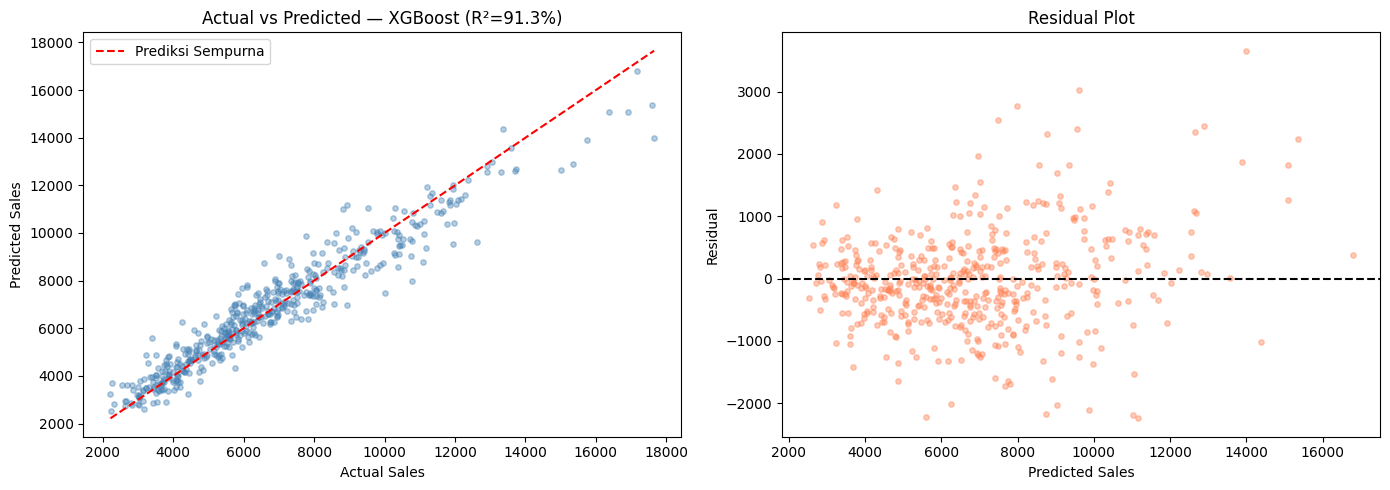

In [34]:
# ====================================================
# Visualisasi: Actual vs Predicted (Model Terbaik)
# ====================================================
best_model = best_boost  # model dengan R2 tertinggi biasanya boosting
y_pred_best = best_model.predict(X_test2)

# Ambil sample 500 untuk visualisasi
sample_idx = np.random.choice(len(y_test2), min(500, len(y_test2)), replace=False)
y_actual_sample = np.array(y_test2)[sample_idx]
y_pred_sample   = y_pred_best[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_actual_sample, y_pred_sample, alpha=0.4, color='steelblue', s=15)
min_val = min(y_actual_sample.min(), y_pred_sample.min())
max_val = max(y_actual_sample.max(), y_pred_sample.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Prediksi Sempurna')
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'Actual vs Predicted — {model3_name} (R²={boost_tuned_r2*100:.1f}%)')
axes[0].legend()

# Residual plot
residuals = y_actual_sample - y_pred_sample
axes[1].scatter(y_pred_sample, residuals, alpha=0.4, color='coral', s=15)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

---
## 8️⃣ MODEL COMPARISON
### Perbandingan Lengkap Semua Model & Split

In [35]:
# Tambahkan hasil tuning ke tabel perbandingan
tuned_results = [
    # Mengganti Linear Regression menjadi LightGBM (Tuned)
    {'Model': 'LightGBM (Tuned)', 'Split': 'Split2_80:20', 
     'R2': round(lgbm_tuned_r2,4), 'R2_pct': round(lgbm_tuned_r2*100,2), 
     'MAE': round(lgbm_tuned_mae,2), 'RMSE': round(lgbm_tuned_rmse,2)},
    
    {'Model': 'Random Forest (Tuned)', 'Split': 'Split2_80:20',
     'R2': round(rf_tuned_r2,4), 'R2_pct': round(rf_tuned_r2*100,2),
     'MAE': round(rf_tuned_mae,2), 'RMSE': round(rf_tuned_rmse,2)},
    
    {'Model': f'{model3_name} (Tuned)', 'Split': 'Split2_80:20',
     'R2': round(boost_tuned_r2,4), 'R2_pct': round(boost_tuned_r2*100,2),
     'MAE': round(boost_tuned_mae,2), 'RMSE': round(boost_tuned_rmse,2)},
]

# Menggabungkan hasil awal (results) dengan hasil tuning (tuned_results)
all_results = results + tuned_results
all_df = pd.DataFrame(all_results)

print('=== TABEL PERBANDINGAN LENGKAP ===')
# Menampilkan kolom yang relevan untuk dibaca dosen
print(all_df[['Model','Split','R2_pct','MAE','RMSE']].to_string(index=False))

=== TABEL PERBANDINGAN LENGKAP ===
                Model        Split  R2_pct     MAE    RMSE
             LightGBM Split1_70:30   87.30  711.84  976.69
             LightGBM Split2_80:20   87.38  712.86  975.57
             LightGBM Split3_90:10   87.68  706.49  966.36
        Random Forest Split1_70:30   71.38 1043.17 1466.10
        Random Forest Split2_80:20   71.74 1037.22 1459.61
        Random Forest Split3_90:10   71.89 1040.36 1459.90
              XGBoost Split1_70:30   78.28  938.60 1277.36
              XGBoost Split2_80:20   78.56  931.98 1271.44
              XGBoost Split3_90:10   78.35  945.11 1281.18
     LightGBM (Tuned) Split2_80:20   92.73  532.13  740.44
Random Forest (Tuned) Split2_80:20   83.90  757.72 1101.91
      XGBoost (Tuned) Split2_80:20   91.27  586.86  811.22
